In [3]:
# -*- coding: utf-8 -*-
"""
Character-based Translation Model
Based on the same architecture as final_task3_part1.py but with character-level processing
"""

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import random
import time
import platform
import logging
from tqdm import tqdm
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import os
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt

# === Device Selection Option ===
DEVICE_OPTION = 'auto'

# Logger setup
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s %(levelname)s: %(message)s')
console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

# Device selection logic
if DEVICE_OPTION == 'cuda' and torch.cuda.is_available():
    device = torch.device('cuda')
    logger.info('Using CUDA (GPU)')
elif DEVICE_OPTION == 'mps' and torch.backends.mps.is_available():
    device = torch.device('mps')
    logger.info('Using Apple Silicon MPS (M1/M2/M3/M4)')
elif DEVICE_OPTION == 'cpu':
    device = torch.device('cpu')
    logger.info('Using CPU')
else:
    if torch.cuda.is_available():
        device = torch.device('cuda')
        logger.info('Auto-selected CUDA (GPU)')
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
        logger.info('Auto-selected Apple Silicon MPS (M1/M2/M3/M4)')
    else:
        device = torch.device('cpu')
        logger.info('Auto-selected CPU')
logger.info(f'Final device: {device}')

# Checkpoint directory
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Load data
print("Loading data for character-based translation...")
eng_sample = pd.read_csv('/kaggle/input/preprocessed-data/eng_preprocessed.csv')
nl_sample = pd.read_csv('/kaggle/input/preprocessed-data/nl_preprocessed.csv')

# Use 30% for faster experimentation
sample_indices = eng_sample.sample(frac=0.3, random_state=42).index
eng_sample = eng_sample.loc[sample_indices].reset_index(drop=True)
nl_sample = nl_sample.loc[sample_indices].reset_index(drop=True)

# Character-level tokenization
def tokenize_characters(sentences):
    return [[char for char in str(sent)] for sent in sentences]

eng_char_tokens = tokenize_characters(eng_sample['sentence'])
nl_char_tokens = [['<SOS>'] + [char for char in str(sent)] + ['<EOS>'] for sent in nl_sample['sentence']]

# Build character vocabularies
def build_char_vocab(char_lists, min_freq=1, max_size=1000):
    counter = Counter(char for sent in char_lists for char in sent)
    vocab = {'<PAD>':0, '<SOS>':1, '<EOS>':2, '<UNK>':3}
    sorted_chars = sorted([c for c in counter if counter[c] >= min_freq],
                          key=lambda c: (-counter[c], c))
    for char in sorted_chars:
        if len(vocab) >= max_size:
            break
        if char not in vocab:
            vocab[char] = len(vocab)
    return vocab

eng_char_vocab = build_char_vocab(eng_char_tokens, min_freq=1, max_size=1000)
nl_char_vocab = build_char_vocab(nl_char_tokens, min_freq=1, max_size=1000)

print("English char vocab size:", len(eng_char_vocab))
print("Dutch char vocab size:", len(nl_char_vocab))

def encode_characters(chars, vocab):
    return [vocab.get(char, vocab['<UNK>']) for char in chars]

eng_char_indices = [encode_characters(sent, eng_char_vocab) for sent in eng_char_tokens]
nl_char_indices = [encode_characters(sent, nl_char_vocab) for sent in nl_char_tokens]

def pad_sequences(sequences, max_len, pad_value=0):
    return [seq + [pad_value]*(max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in sequences]

# Character sequences are typically longer than word sequences
max_len_eng_char = min(200, max(len(seq) for seq in eng_char_indices))
max_len_nl_char = min(200, max(len(seq) for seq in nl_char_indices))

eng_char_padded = pad_sequences(eng_char_indices, max_len_eng_char)
nl_char_padded = pad_sequences(nl_char_indices, max_len_nl_char)

# Compute lengths for packing
eng_char_lengths = [min(len(seq), max_len_eng_char) for seq in eng_char_indices]

# Split data
X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
    eng_char_padded, nl_char_padded, eng_char_lengths, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val, len_train, len_val = train_test_split(
    X_train, y_train, len_train, test_size=0.1, random_state=42)

# Character-based Dataset
class CharTranslationDataset(Dataset):
    def __init__(self, src, tgt, src_lengths):
        self.src = torch.tensor(src, dtype=torch.long)
        self.tgt = torch.tensor(tgt, dtype=torch.long)
        self.src_lengths = torch.tensor(src_lengths, dtype=torch.long)
    def __len__(self):
        return len(self.src)
    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx], self.src_lengths[idx]

train_ds = CharTranslationDataset(X_train, y_train, len_train)
val_ds = CharTranslationDataset(X_val, y_val, len_val)
test_ds = CharTranslationDataset(X_test, y_test, len_test)

# Smaller batch size for character-based models due to longer sequences
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

# --- Character-based Encoder ---
class CharEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=2,  # More layers for character-level processing
            batch_first=True,
            dropout=dropout
        )

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed_embedded = pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_outputs, hidden = self.rnn(packed_embedded)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True)
        return hidden

# --- Character-based Decoder ---
class CharDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=2,  # More layers for character-level processing
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

# --- Character-based Seq2Seq ---
class CharSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.8):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)

        hidden = self.encoder(src, src_lengths)
        input = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = tgt[:, t] if teacher_force else top1

        return outputs

# Best configuration for character-based model
best_config_char = {
    "lr": 0.001,  # Higher learning rate for character-based
    "tf_base": 0.9,  # Higher teacher forcing
    "tf_decay": 0.99,  # Slower decay
    "dropout": 0.3,  # Lower dropout
    "hidden_dim": 256,
    "emb_dim": 128,  # Smaller embedding for characters
    "n_layers": 1
}

# Label smoothing loss
def label_smoothed_nll_loss(logits, target, epsilon=0.1):
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(-1)).squeeze(-1)
    smooth_loss = -log_probs.mean(dim=-1)
    loss = (1 - epsilon) * nll_loss + epsilon * smooth_loss
    return loss.mean()

# Initialize character-based model
encoder = CharEncoder(len(eng_char_vocab), emb_dim=best_config_char['emb_dim'], 
                      hidden_dim=best_config_char['hidden_dim'], 
                      dropout=best_config_char['dropout']).to(device)
decoder = CharDecoder(len(nl_char_vocab), emb_dim=best_config_char['emb_dim'], 
                      hidden_dim=best_config_char['hidden_dim'], 
                      dropout=best_config_char['dropout']).to(device)
model = CharSeq2Seq(encoder, decoder, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_config_char['lr'], weight_decay=1e-5)
criterion = torch.nn.CrossEntropyLoss(ignore_index=0)

# Training and evaluation functions for character-based model
def train_char(model, loader, optimizer, criterion, epoch, teacher_forcing_ratio=0.8):
    model.train()
    total_loss, total_acc, count = 0, 0, 0

    loop = tqdm(loader, desc=f"Training Epoch {epoch+1} (Char-based)", leave=False)

    for src, tgt, src_lengths in loop:
        src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
        optimizer.zero_grad()
        output = model(src, src_lengths, tgt, teacher_forcing_ratio)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        tgt = tgt[:, 1:].reshape(-1)

        loss = label_smoothed_nll_loss(output, tgt, epsilon=0.1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = output.argmax(1)
        total_acc += (preds == tgt).float().mean().item()
        count += 1

        loop.set_postfix(loss=loss.item())

    return total_loss / count, total_acc / count

def evaluate_char(model, loader, criterion):
    model.eval()
    total_loss, total_acc, count = 0, 0, 0

    loop = tqdm(loader, desc="Evaluating (Char-based)", leave=False)

    with torch.no_grad():
        for src, tgt, src_lengths in loop:
            src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            tgt = tgt[:, 1:].reshape(-1)

            loss = label_smoothed_nll_loss(output, tgt, epsilon=0.1)
            total_loss += loss.item()
            preds = output.argmax(1)
            total_acc += (preds == tgt).float().mean().item()
            count += 1

            loop.set_postfix(val_loss=loss.item())

    return total_loss / count, total_acc / count

def compute_char_bleu(model, loader, tgt_vocab):
    model.eval()
    references = []
    hypotheses = []
    sos_idx = tgt_vocab['<SOS>'] if '<SOS>' in tgt_vocab else 1
    eos_idx = tgt_vocab['<EOS>'] if '<EOS>' in tgt_vocab else 2
    
    with torch.no_grad():
        for src, tgt, src_lengths in loader:
            src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)
            pred_tokens = output.argmax(-1).cpu().numpy()
            tgt_tokens = tgt.cpu().numpy()
            
            for ref, hyp in zip(tgt_tokens, pred_tokens):
                ref_seq = [idx for idx in ref if idx != 0 and idx != sos_idx]
                hyp_seq = [idx for idx in hyp if idx != 0 and idx != sos_idx]
                
                if eos_idx in ref_seq:
                    ref_seq = ref_seq[:ref_seq.index(eos_idx)]
                if eos_idx in hyp_seq:
                    hyp_seq = hyp_seq[:hyp_seq.index(eos_idx)]
                    
                references.append([ref_seq])
                hypotheses.append(hyp_seq)
    
    bleu = corpus_bleu(references, hypotheses)
    return bleu

# Training loop for character-based model
print("Starting character-based translation training...")
patience = 8  # More patience for character-based models
min_delta = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(25):  # More epochs for character-based models
    teacher_forcing_ratio = best_config_char['tf_base'] * (best_config_char['tf_decay'] ** epoch)

    train_loss, train_acc = train_char(
        model, train_loader, optimizer, criterion, epoch,
        teacher_forcing_ratio=teacher_forcing_ratio
    )

    val_loss, val_acc = evaluate_char(model, val_loader, criterion)

    print(f"Epoch {epoch+1} | TF Ratio: {teacher_forcing_ratio:.4f} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Early stopping check
    if best_val_loss - val_loss > min_delta:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model_char.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


2025-07-28 10:35:36,627 INFO: Auto-selected CUDA (GPU)
2025-07-28 10:35:36,627 INFO: Auto-selected CUDA (GPU)
2025-07-28 10:35:36,627 INFO: Auto-selected CUDA (GPU)
2025-07-28 10:35:36,629 INFO: Final device: cuda
2025-07-28 10:35:36,629 INFO: Final device: cuda
2025-07-28 10:35:36,629 INFO: Final device: cuda


Loading data for character-based translation...
English char vocab size: 126
Dutch char vocab size: 125
Starting character-based translation training...


Epoch 1 | TF Ratio: 0.9000 | Train Loss: 1.8362, Train Acc: 0.6608 | Val Loss: 5.7015, Val Acc: 0.0617


Epoch 2 | TF Ratio: 0.8910 | Train Loss: 1.6452, Train Acc: 0.7210 | Val Loss: 5.3433, Val Acc: 0.1549


Epoch 3 | TF Ratio: 0.8821 | Train Loss: 1.6159, Train Acc: 0.7312 | Val Loss: 5.4651, Val Acc: 0.1396


...

Epoch 21 | TF Ratio: 0.7361 | Train Loss: 1.7155, Train Acc: 0.7045 | Val Loss: 3.7409, Val Acc: 0.3837


Epoch 22 | TF Ratio: 0.7288 | Train Loss: 1.7263, Train Acc: 0.7013 | Val Loss: 3.5639, Val Acc: 0.4067


Epoch 23 | TF Ratio: 0.7215 | Train Loss: 1.7343, Train Acc: 0.6989 | Val Loss: 3.5250, Val Acc: 0.3984


Epoch 24 | TF Ratio: 0.7143 | Train Loss: 1.7429, Train Acc: 0.6962 | Val Loss: 3.5767, Val Acc: 0.3760


Epoch 25 | TF Ratio: 0.7071 | Train Loss: 1.7512, Train Acc: 0.6936 | Val Loss: 3.6170, Val Acc: 0.3446


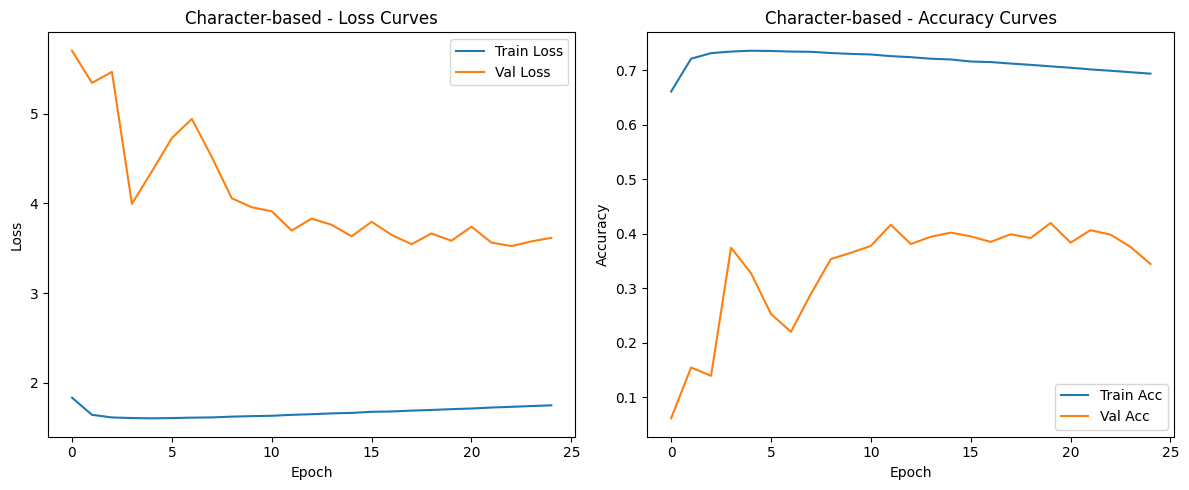

Final Validation BLEU (Character-based): 0.2107
Character-based training completed!
Results saved to: task3/char_results.pkl
Best model saved to: best_model_char.pt


In [ ]:
# Plot results
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Character-based - Loss Curves')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Character-based - Accuracy Curves')

plt.tight_layout()
plt.savefig('/kaggle/working/character_based_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Compute BLEU score
val_bleu = compute_char_bleu(model, val_loader, nl_char_vocab)
print(f"Final Validation BLEU (Character-based): {val_bleu:.4f}")

# Save results for comparison
char_results = {
    'model_type': 'character_based',
    'direction': 'English_to_Dutch',
    'final_val_loss': val_losses[-1],
    'final_val_acc': val_accs[-1],
    'final_val_bleu': val_bleu,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'vocab_sizes': {'source': len(eng_char_vocab), 'target': len(nl_char_vocab)}
}

import pickle
with open('/kaggle/working/char_results.pkl', 'wb') as f:
    pickle.dump(char_results, f)

print("Character-based training completed!")
print(f"Results saved to: task3/char_results.pkl")
print(f"Best model saved to: best_model_char.pt") 